In [2]:
#Packages
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:

  
# fetch dataset 
ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601) 
# data (as pandas dataframes) 
x = ai4i_2020_predictive_maintenance_dataset.data.features 
y = ai4i_2020_predictive_maintenance_dataset.data.targets 
  
# metadata 
print(ai4i_2020_predictive_maintenance_dataset.metadata) 
  
# variable information 
print(ai4i_2020_predictive_maintenance_dataset.variables) 

print(x.columns.to_list())
print(y.columns.to_list())

{'uci_id': 601, 'name': 'AI4I 2020 Predictive Maintenance Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/601/data.csv', 'abstract': 'The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression', 'Causal-Discovery'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 10000, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], 'index_col': ['UID', 'Product ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C5HS5C', 'creators': [], 'intro_paper': {'ID': 386, 'type': 'NATIVE', 'title': 'Explainable Artificial Intelligen

In [11]:
result = pd.concat([x,y], axis =1)
display(result.head())

result.describe()


failure_modes_any = result[['TWF','HDF','PWF','OSF','RNF']].any(axis=1)
mismatch = sum(failure_modes_any)
print(mismatch)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


348


In [8]:
print(result["Machine failure"].value_counts())
print(result["Machine failure"].value_counts(normalize = True))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


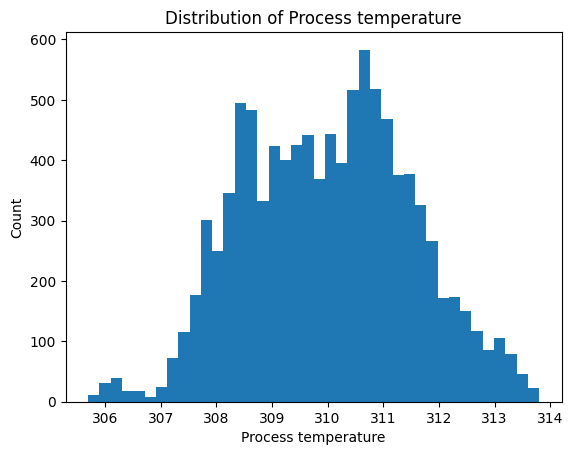

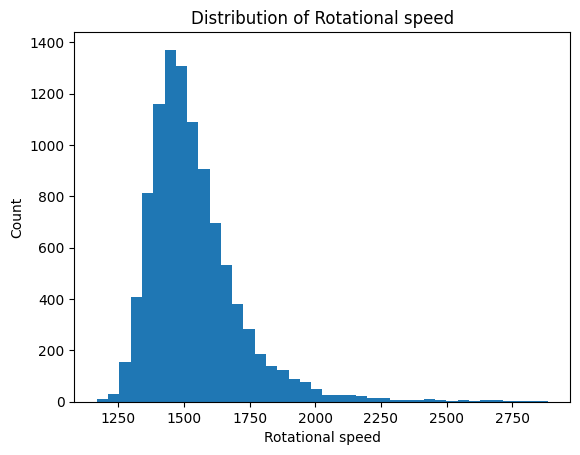

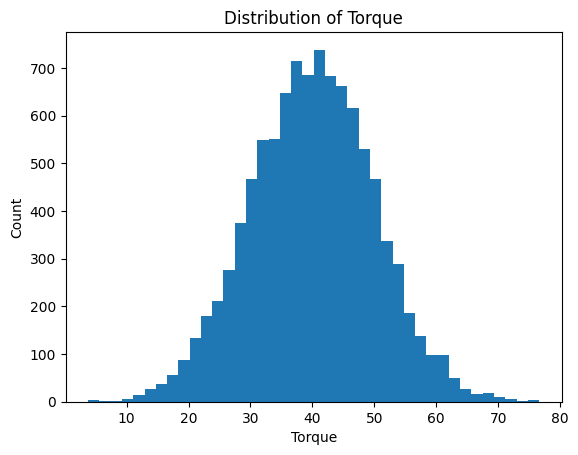

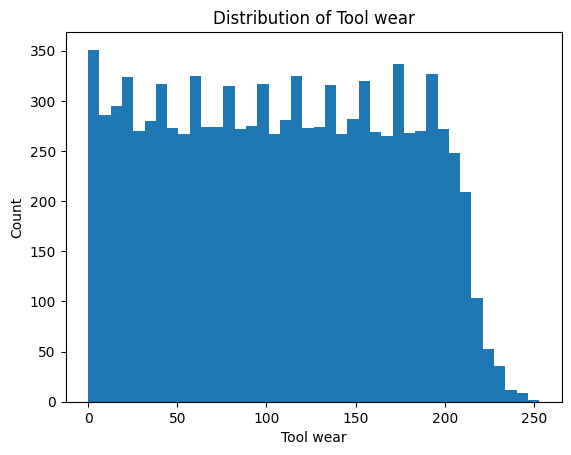

In [18]:
def makeHistogram(colName):

    plt.hist(result[colName], bins = 40)
    plt.xlabel(f"{colName}")
    plt.ylabel("Count")
    plt.title(f"Distribution of {colName}")
    plt.show()

cols = result.iloc[:,2:6]

for feature in cols:
    makeHistogram(feature)

The dataset is a synthetic dataset for predictive maintenance with 14 features. Each record is categorised into normal/failure, I will be predicting if a failure event has occured using selected relevant features.

Fault percentage 3.39%

I dropped the TWF/HDF/PWF/OSF/RNF features as they label what type of failure event occured, they are post-hoc labels added after the failure event not used to predict it. Including them would make the model triivally artifically perfect. This would make the project useless as it would not learn to use the real time sensor data to predict if a fault was likely to occur thus not saving any money in equipment damage or improving safety.